# Tipos de Média, Distribuições e Probabilidade — Ibovespa

**Atividade:** Tipos de média · Distribuições de dados · Probabilidade e seus tipos · Conceito de modelo  
**Dataset:** Retornos diários do Ibovespa (^BVSP) — 2000 a 2025  
**Fonte:** Yahoo Finance via `yfinance`

---

## Contexto

O Ibovespa é o principal índice da bolsa brasileira — uma carteira teórica com as ações de maior liquidez e volume. Com mais de 6.000 pregões disponíveis, sua série histórica é ideal para visualizar:

- Como os **tipos de média** respondem perguntas diferentes sobre o mesmo dado
- Que os retornos têm uma **distribuição própria** — próxima da normal, mas com caudas mais pesadas
- Como **probabilidade** quantifica a incerteza em mercados reais

## 1. Bibliotecas

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (11, 4)
sns.set_theme(style="whitegrid", palette="muted")

## 2. Download dos Dados

In [76]:
ibov = yf.download("^BVSP", start="2000-01-01", end="2025-03-31", auto_adjust=True)

preco = ibov["Close"].dropna()
retorno = preco.pct_change().dropna()

print(f"Periodo   : {preco.index[0].date()} -> {preco.index[-1].date()}")
print(f"Pregoes   : {len(preco):,}")
print(f"Retornos  : {len(retorno):,}")
print(f"\nIndice no inicio : {float(preco.iloc[0]):,.0f} pontos")
print(f"Indice no final  : {float(preco.iloc[-1]):,.0f} pontos")

# p_pos calculado aqui para ficar disponível em todas as seções
p_pos = (retorno.values.flatten() > 0).mean()


[*********************100%***********************]  1 of 1 completed

Periodo   : 2000-01-03 -> 2025-03-28
Pregoes   : 6,251
Retornos  : 6,250

Indice no inicio : 16,930 pontos
Indice no final  : 131,902 pontos


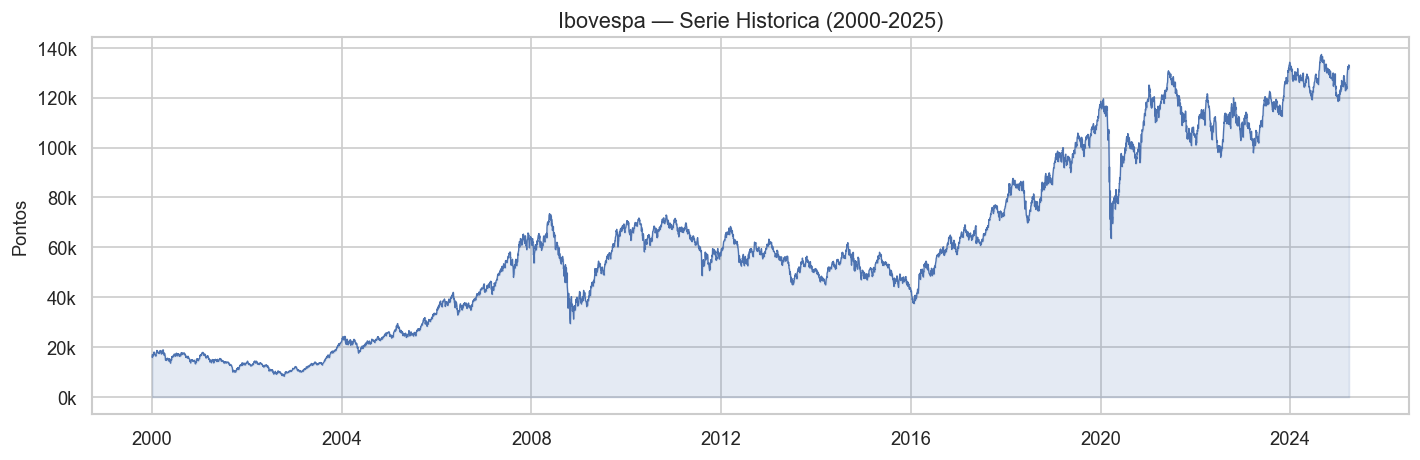

In [77]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(preco.index, preco.values, color="#4C72B0", linewidth=0.8)
ax.fill_between(preco.index, preco.values.flatten(), alpha=0.15, color="#4C72B0")
ax.set_ylabel("Pontos", fontsize=11)
ax.set_title("Ibovespa — Serie Historica (2000-2025)", fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.tight_layout()
plt.show()

## 3. Tipos de Média

A ideia principal em uma média matemática é a mesma em todos os tipos: encontrar uma relação numérica central. Entretanto, a fórmula como esse valor é calculado pode trazer diferentes interpretações. A depender do tipo de média há uma correção de pesos para cada valor, ou ainda para encontrar a média de uma progressão geométrica.
A palavra **média** é ambígua — existem quatro tipos principais, cada um respondendo a uma pergunta diferente:

| Tipo | Pergunta respondida | Quando usar |
|------|--------------------|--------------|
| **Aritmética** | Qual é o retorno típico de um único dia? | Estimativa de retorno esperado |
| **Ponderada** | Qual é o retorno médio priorizando dados recentes? | Modelos com decaimento temporal |
| **Geométrica** | A que taxa o índice cresceu de forma composta? | Retorno anualizado real (CAGR) |
| **Harmônica** | Qual é a média de razões ou taxas? | Custo médio em aportes periódicos |

---

### 3.1 Média Aritmética

É a soma de todos os valores dividida pelo número de observações. Simples e intuitiva, mas **sensível a outliers**: um único pregão com queda de 10% (como em 2008) puxa a média para baixo de forma desproporcional. Funciona bem quando os dados são simétricos e sem extremos.

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

onde $n$ é a quantidade de elementos e $x_i$ é cada valor individual do conjunto de dados. 

### 3.2 Média Ponderada

Permite atribuir **importâncias diferentes** a cada observação via peso $w_i$. Quando os pesos são iguais, reduz-se à aritmética. Usar pesos crescentes no tempo faz os pregões recentes valerem mais — útil quando o comportamento do mercado muda ao longo dos anos.

$$\bar{x}_w = \frac{\sum_{i=1}^{n} w_i \cdot x_i}{\sum_{i=1}^{n} w_i}$$

onde $n$ é a quantidade de elementos, $w_i$ é o peso associado e $x_i$ é cada valor individual do conjunto de dados.

### 3.3 Média Geométrica

É a **taxa diária constante** que, composta em $n$ pregões, reproduz exatamente o retorno acumulado. A aritmética sempre superestima o crescimento real — a geométrica é o que o investidor realmente obteve. Por isso é o padrão para calcular o CAGR de qualquer ativo.

$$\bar{x}_g = \left(\prod_{i=1}^{n} x_i\right)^{1/n} - 1$$

onde $n$ é a quantidade de elementos e $x_i$ é cada valor individual do conjunto de dados. 

### 3.4 Média Harmônica

É a média correta quando se trabalha com **taxas ou razões**. No contexto de investimentos: ao aportar o mesmo valor em reais todo mês (dollar-cost averaging), o preço médio de compra é a harmônica dos preços pagos — sempre menor que a aritmética, pois meses com preço baixo resultam em mais cotas compradas, reduzindo o custo médio.

$$\bar{x}_h = \frac{n}{\displaystyle\sum_{i=1}^{n} \frac{1}{x_i}}$$

onde $n$ é a quantidade de elementos e $x_i$ é cada valor individual do conjunto de dados. 

In [78]:
ret_vals = retorno.values.flatten()
n = len(ret_vals)

media_arit = ret_vals.mean()
media_geom = (1 + ret_vals).prod() ** (1 / n) - 1
pesos = np.arange(1, n + 1, dtype=float)
media_pond = np.average(ret_vals, weights=pesos)
fatores = 1 + ret_vals
media_harm_ret = len(fatores) / (1.0 / fatores).sum() - 1

print("Retorno diario medio do Ibovespa (2000-2025):")
print(f"  Aritmetica : {media_arit*100:+.4f}%")
print(f"  Ponderada  : {media_pond*100:+.4f}%  (peso maior para dados recentes)")
print(f"  Geometrica : {media_geom*100:+.4f}%  (taxa real composta)")
print(f"  Harmonica  : {media_harm_ret*100:+.4f}%")

retorno_acum = (1 + ret_vals).prod() - 1
print(f"\nRetorno acumulado no periodo:")
print(f"  Via geometrica (correto)       : {retorno_acum*100:+,.1f}%")
print(f"  Via aritmetica x n (incorreto) : {media_arit * n * 100:+,.1f}%  <- superestimativa")

Retorno diario medio do Ibovespa (2000-2025):
  Aritmetica : +0.0476%
  Ponderada  : +0.0438%  (peso maior para dados recentes)
  Geometrica : +0.0329%  (taxa real composta)
  Harmonica  : +0.0180%

Retorno acumulado no periodo:
  Via geometrica (correto)       : +679.1%
  Via aritmetica x n (incorreto) : +297.8%  <- superestimativa


In [79]:
periodos = {
    "2000-2009": ("2000-01-01", "2009-12-31"),
    "2010-2019": ("2010-01-01", "2019-12-31"),
    "2020-2025": ("2020-01-01", "2025-03-31"),
    "2000-2025": ("2000-01-01", "2025-03-31"),
}

print("CAGR (Retorno Geometrico Anualizado) por periodo:")
print("-" * 55)
for label, (ini, fim) in periodos.items():
    ret_p = retorno.loc[ini:fim].values.flatten()
    anos = len(ret_p) / 252
    cagr = (1 + ret_p).prod() ** (1 / anos) - 1
    arit = ret_p.mean() * 252
    print(f"  {label}  |  Geometrica: {cagr*100:+.1f}%/ano  |  Aritmetica: {arit*100:+.1f}%/ano")

CAGR (Retorno Geometrico Anualizado) por periodo:
-------------------------------------------------------
  2000-2009  |  Geometrica: +15.3%/ano  |  Aritmetica: +19.4%/ano
  2010-2019  |  Geometrica: +5.5%/ano  |  Aritmetica: +7.9%/ano
  2020-2025  |  Geometrica: +2.5%/ano  |  Aritmetica: +5.8%/ano
  2000-2025  |  Geometrica: +8.6%/ano  |  Aritmetica: +12.0%/ano


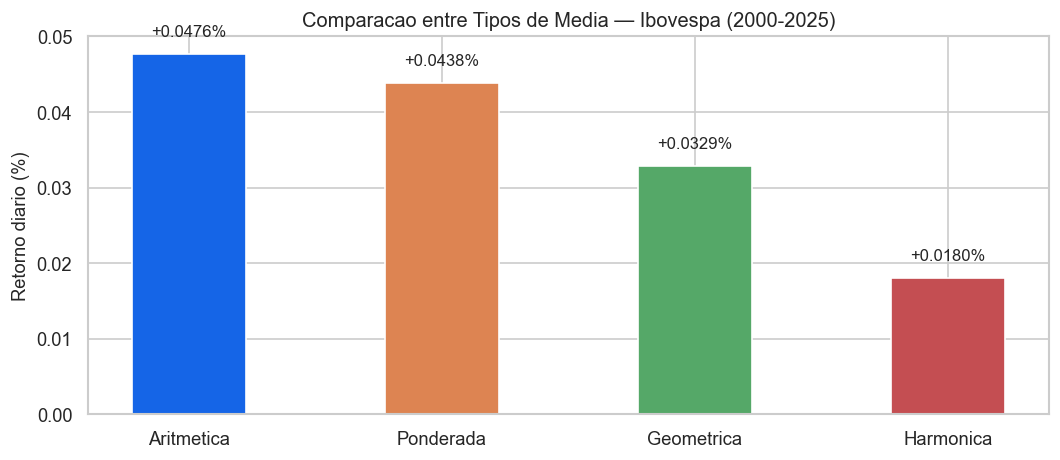

In [80]:
medias = {
    "Aritmetica": media_arit * 100,
    "Ponderada": media_pond * 100,
    "Geometrica": media_geom * 100,
    "Harmonica": media_harm_ret * 100,
}
cores = ["#1565E7", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(list(medias.keys()), list(medias.values()), color=cores, edgecolor="white", width=0.45)
ax.axhline(0, color="gray", linewidth=0.8)
for bar, val in zip(bars, medias.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
            f"{val:+.4f}%", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Retorno diario (%)", fontsize=11)
ax.set_title("Comparacao entre Tipos de Media — Ibovespa (2000-2025)", fontsize=12)
plt.tight_layout()
plt.show()

### 3.5 Média Harmônica — Exemplo DCA com Ibovespa

Ao investir o mesmo valor em reais todo mês (*dollar-cost averaging*), o preço médio de compra é a **média harmônica** dos preços pagos, não a aritmética. Isso acontece porque meses com preço baixo geram mais cotas — e a harmônica naturalmente dá mais peso às observações menores.

In [81]:
# Preço mensal do Ibovespa (fechamento do último pregão de cada mês)
preco_mensal = preco.resample('ME').last().dropna()
preco_m = preco_mensal.values.flatten()

aporte_mensal = 1000.0  # R$ 1.000 por mês

# Cotas compradas a cada mês
cotas_compradas = aporte_mensal / preco_m

# Preço médio real = total investido / total de cotas
total_investido = aporte_mensal * len(preco_m)
total_cotas     = cotas_compradas.sum()
preco_medio_real = total_investido / total_cotas

# Média aritmética dos preços
media_arit_preco = preco_m.mean()

# Média harmônica dos preços
media_harm_preco = len(preco_m) / (1.0 / preco_m).sum()

print('DCA — Ibovespa mensal (2000-2025):')
print(f'  Meses de aporte         : {len(preco_m)}')
print(f'  Total investido          : R$ {total_investido:,.0f}')
print(f'  Total de cotas           : {total_cotas:.4f}')
print(f'\n  Preço médio real (DCA)   : {preco_medio_real:,.0f} pontos')
print(f'  Média harmônica          : {media_harm_preco:,.0f} pontos  <- igual ao preço médio real')
print(f'  Média aritmética         : {media_arit_preco:,.0f} pontos  <- superestima o custo médio')
print(f'\n  Diferença aritmética - harmônica: {media_arit_preco - media_harm_preco:,.0f} pontos')
print('  -> A harmônica é sempre <= aritmética quando os valores diferem entre si.')


DCA — Ibovespa mensal (2000-2025):
  Meses de aporte         : 303
  Total investido          : R$ 303,000
  Total de cotas           : 8.0398

  Preço médio real (DCA)   : 37,688 pontos
  Média harmônica          : 37,688 pontos  <- igual ao preço médio real
  Média aritmética         : 61,566 pontos  <- superestima o custo médio

  Diferença aritmética - harmônica: 23,879 pontos
  -> A harmônica é sempre <= aritmética quando os valores diferem entre si.


> **Conexão:** com as médias calculadas, uma pergunta natural surge: esses valores são representativos de todos os dias, ou alguns pregões distorcem muito o resultado? Para responder isso, precisamos entender a **forma** dos dados — ou seja, sua distribuição.

## 4. Distribuições de Dados

Uma **distribuição** descreve como os valores de uma variável estão organizados — quais são comuns, quais são raros e qual é a forma geral. Conhecer a distribuição dos dados permite escolher o modelo estatístico correto e calcular probabilidades.

---

### 4.1 Distribuição Normal

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \, e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

Simétrica em torno da média, com formato de sino. A **regra empírica** diz que ~68% dos valores estão em $\mu \pm 1\sigma$, ~95% em $\mu \pm 2\sigma$ e ~99,7% em $\mu \pm 3\sigma$. É a hipótese padrão para retornos financeiros — mesmo que na prática os retornos do Ibovespa se desviem dela nas caudas, onde eventos extremos ocorrem com mais frequência do que a fórmula prevê.

### 4.2 Distribuição Binomial

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Modela o número de sucessos $k$ em $n$ tentativas independentes, cada uma com probabilidade $p$ de sucesso. É discreta — só assume valores inteiros. Aplicação direta: quantos dias o Ibovespa fecha em alta em um universo de $n$ pregões, dado que a probabilidade histórica de alta é $p$.


In [82]:
mu = ret_vals.mean()
sigma = ret_vals.std()
kurt = float(retorno.kurt())
skew = float(retorno.skew())

print("Estatisticas dos retornos diarios (2000-2025):")
print(f"  Media            : {mu*100:.4f}%")
print(f"  Desvio padrao    : {sigma*100:.4f}%")
print(f"  Assimetria       : {skew:.4f}  (normal = 0)")
print(f"  Curtose (excesso): {kurt:.4f}  (normal = 0, positivo = caudas pesadas)")

Estatisticas dos retornos diarios (2000-2025):
  Media            : 0.0476%
  Desvio padrao    : 1.7180%
  Assimetria       : -0.1202  (normal = 0)
  Curtose (excesso): 6.5530  (normal = 0, positivo = caudas pesadas)


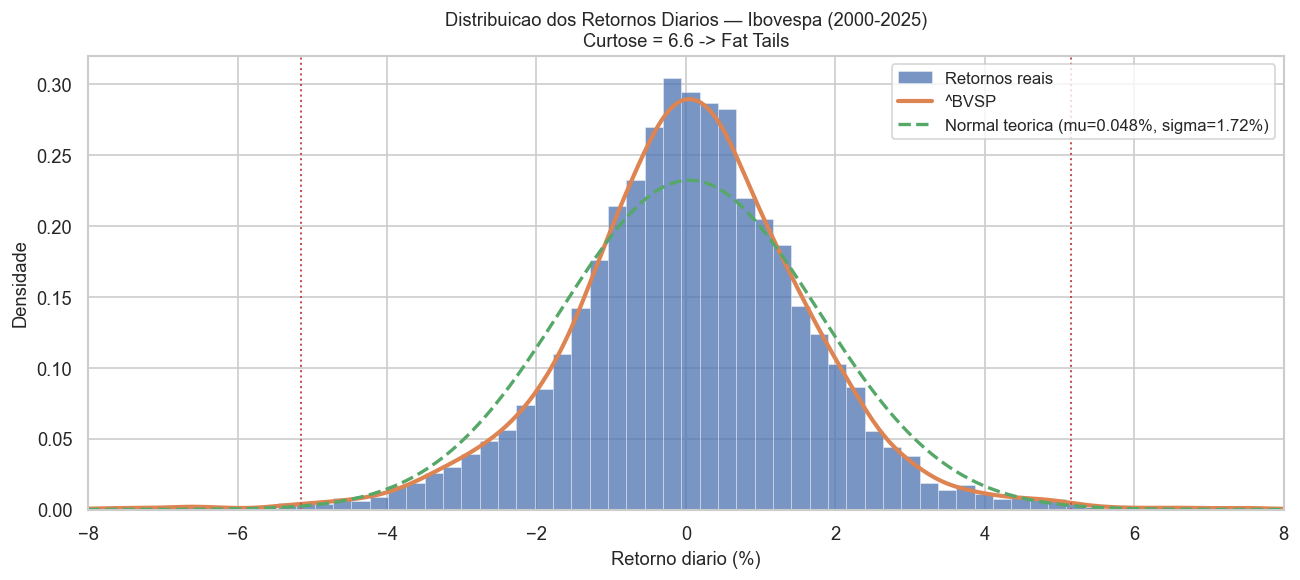

In [83]:
x = np.linspace(np.quantile(ret_vals, 0.001), np.quantile(ret_vals, 0.999), 500)
normal_pdf = stats.norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(ret_vals * 100, bins=120, density=True,
        color="#4C72B0", edgecolor="white", linewidth=0.3, alpha=0.75, label="Retornos reais")
(retorno * 100).plot.kde(ax=ax, color="#DD8452", linewidth=2.5, label="KDE (forma real)")
ax.plot(x * 100, normal_pdf / 100, color="#55A868", linewidth=2,
        linestyle="--", label=f"Normal teorica (mu={mu*100:.3f}%, sigma={sigma*100:.2f}%)")
limiar = 3 * sigma
ax.axvline(-limiar * 100, color="#C44E52", linewidth=1.2, linestyle=":")
ax.axvline(+limiar * 100, color="#C44E52", linewidth=1.2, linestyle=":")
ax.set_xlabel("Retorno diario (%)", fontsize=11)
ax.set_ylabel("Densidade", fontsize=11)
ax.set_title(f"Distribuicao dos Retornos Diarios — Ibovespa (2000-2025)\nCurtose = {kurt:.1f} -> Fat Tails", fontsize=11)
ax.set_xlim(-8, 8)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

O histograma sugere que os retornos se aproximam da normal — mas se desviam nas extremidades. O **QQ-plot** torna esse desvio explícito: compara os quantis observados com os quantis teóricos da normal. Se os dados fossem perfeitamente normais, todos os pontos cairiam sobre a linha. O afastamento nas caudas revela os **eventos extremos mais frequentes do que o previsto** — propriedade conhecida como *fat tails*, fundamental para o dimensionamento correto do risco.

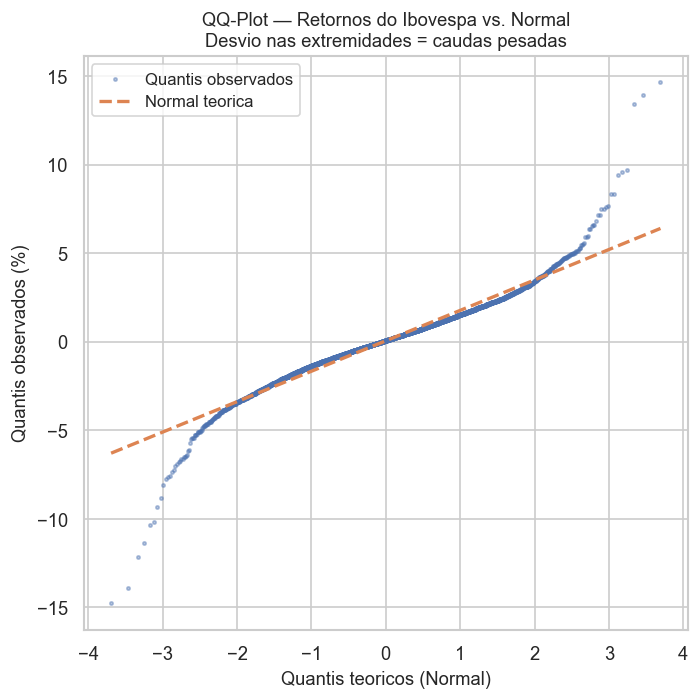

Eventos alem de 3 sigma:
  Observados        : 65 dias (1.04%)
  Esperados (normal): 19 dias (0.30%)
  -> 3.5x mais eventos extremos do que a normal preve


In [84]:
fig, ax = plt.subplots(figsize=(6, 6))
qq = stats.probplot(ret_vals, dist="norm", plot=None)
teor, obs = qq[0]
ax.scatter(teor, obs * 100, s=4, alpha=0.4, color="#4C72B0", label="Quantis observados")
x_ref = np.array([teor.min(), teor.max()])
ax.plot(x_ref, (mu + sigma * x_ref) * 100, color="#DD8452", linewidth=2, linestyle="--", label="Normal teorica")
ax.set_xlabel("Quantis teoricos (Normal)", fontsize=11)
ax.set_ylabel("Quantis observados (%)", fontsize=11)
ax.set_title("QQ-Plot — Retornos do Ibovespa vs. Normal\nDesvio nas extremidades = caudas pesadas", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

extremos = ret_vals[np.abs(ret_vals) > 3 * sigma]
esperado_normal = len(ret_vals) * 0.003
print(f"Eventos alem de 3 sigma:")
print(f"  Observados        : {len(extremos):,} dias ({len(extremos)/len(ret_vals)*100:.2f}%)")
print(f"  Esperados (normal): {esperado_normal:.0f} dias (0.30%)")
print(f"  -> {len(extremos)/esperado_normal:.1f}x mais eventos extremos do que a normal preve")

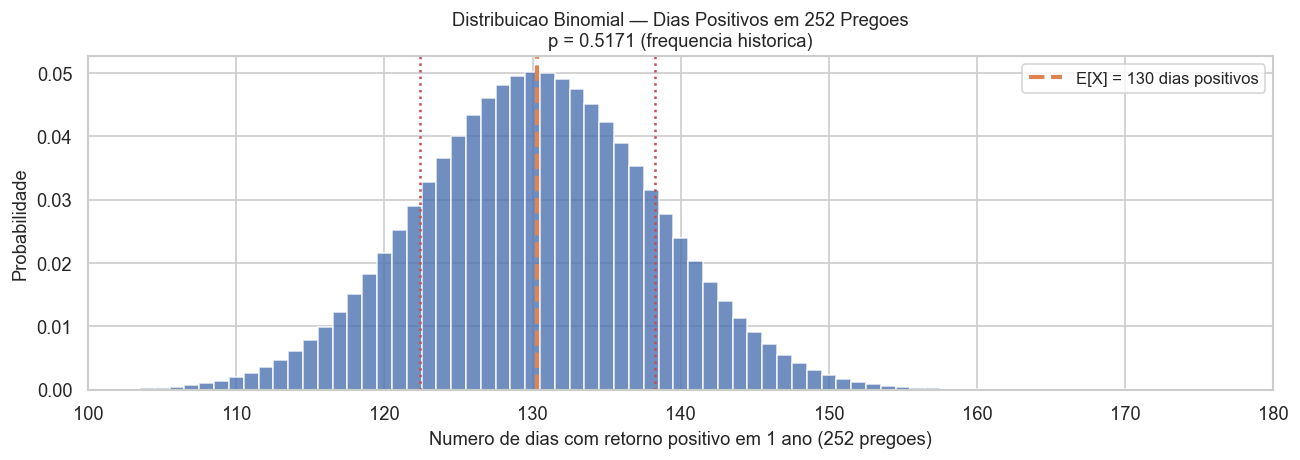

Em 252 pregoes, com base na frequencia historica:
  Esperanca (dias positivos) : 130
  Desvio padrao              : 7.9 dias
  P(>= 140 dias positivos)   : 0.1234
  P(<  120 dias positivos)   : 0.0864


In [85]:
n_pregoes = 252
k_vals = np.arange(0, n_pregoes + 1)
prob_binom = stats.binom.pmf(k_vals, n_pregoes, p_pos)
esperanca = n_pregoes * p_pos
dp_binom  = np.sqrt(n_pregoes * p_pos * (1 - p_pos))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(k_vals, prob_binom, color="#4C72B0", alpha=0.8, width=1.0)
ax.axvline(esperanca, color="#DD8452", linewidth=2.5, linestyle="--",
           label=f"E[X] = {esperanca:.0f} dias positivos")
ax.axvline(esperanca - dp_binom, color="#C44E52", linewidth=1.5, linestyle=":")
ax.axvline(esperanca + dp_binom, color="#C44E52", linewidth=1.5, linestyle=":")
ax.set_xlabel("Numero de dias com retorno positivo em 1 ano (252 pregoes)", fontsize=11)
ax.set_ylabel("Probabilidade", fontsize=11)
ax.set_title(f"Distribuicao Binomial — Dias Positivos em 252 Pregoes\np = {p_pos:.4f} (frequencia historica)", fontsize=11)
ax.set_xlim(100, 180)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Em 252 pregoes, com base na frequencia historica:")
print(f"  Esperanca (dias positivos) : {esperanca:.0f}")
print(f"  Desvio padrao              : {dp_binom:.1f} dias")
print(f"  P(>= 140 dias positivos)   : {1 - stats.binom.cdf(139, n_pregoes, p_pos):.4f}")
print(f"  P(<  120 dias positivos)   : {stats.binom.cdf(119, n_pregoes, p_pos):.4f}")

> **Conexão:** agora que sabemos que os retornos do Ibovespa seguem uma distribuição aproximadamente normal — com caudas mais pesadas do que o previsto — podemos usar essa estrutura para calcular probabilidades. A seção a seguir formaliza o que é probabilidade e como ela se relaciona com as distribuições que acabamos de explorar.

## 5. O que é Probabilidade?

Uma função $P(\cdot)$ é denominada probabilidade se satisfaz as condições:

i. $0 \leq P(A) \leq 1$, $\forall A \subset \Omega$

ii. $P(\Omega) = 1$

iii. $P\left(\bigcup_{j=1}^{n} A_j \right) = \sum_{j=1}^{n} P(A_j)$, com os $A_j$ disjuntos.

onde $(\Omega)$ é o espaço amostral, ou seja, o conjunto de todos os resultados possíveis de um certo fenômeno aleatório; $A$ é um evento, ou seja, subconjunto do espaço amostral.

### 5.1 Propriedades de Probabilidade

A partir dos axiomas, derivam-se as seguintes propriedades:

**P1 — Evento impossível**

$$P(\emptyset) = 0$$

O conjunto vazio (evento sem resultados possíveis) tem probabilidade zero.

**P2 — Complementar**

$$P(A^c) = 1 - P(A)$$

A probabilidade de um evento *não* ocorrer é o complemento de ele ocorrer. No Ibovespa: se $P(\text{dia positivo}) = 0{,}543$, então $P(\text{dia não positivo}) = 0{,}457$.

**P3 — Adição (eventos não disjuntos)**

$$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

Ao somar $P(A)$ e $P(B)$, a interseção é contada duas vezes — por isso ela é subtraída. Se $A$ e $B$ forem disjuntos, $P(A \cap B) = 0$ e a fórmula reduz ao axioma iii.

**P4 — Monotonicidade**

$$\text{Se } A \subset B \text{, então } P(A) \leq P(B)$$

Se um evento $A$ está contido em $B$, ele não pode ser mais provável que $B$. Exemplo: $P(\text{alta} > 2\%) \leq P(\text{alta} > 0\%)$.

## 6. Tipos de Probabilidade

---

### 6.1 Tipos Conceituais

Dizem respeito à **interpretação** do que é probabilidade — de onde ela vem e o que ela representa.

**Clássica (Laplaciana)**

$$P(A) = \frac{\text{número de casos favoráveis a } A}{\text{número total de casos igualmente prováveis}}$$

Pressupõe que todos os resultados do espaço amostral são equiprováveis. Funciona bem em jogos de azar (dados, moedas), mas tem aplicação limitada em finanças — os retornos do Ibovespa não são equiprováveis.

**Frequentista**

$$P(A) = \lim_{n \to \infty} \frac{n_A}{n}$$

onde $n_A$ é o número de vezes que $A$ ocorreu em $n$ experimentos. A probabilidade é a frequência relativa estabilizada ao longo de muitas repetições. É a base da estatística clássica e do que fazemos ao calcular $P(\text{dia positivo})$ a partir do histórico do Ibovespa.

**Subjetiva**

É o grau de crença pessoal de um indivíduo sobre a ocorrência de um evento, expresso como um número entre 0 e 1. Não exige repetição do experimento — é válida mesmo para eventos únicos. Exemplo: a probabilidade que um gestor atribui a uma queda do Ibovespa amanhã, com base em sua leitura do cenário macroeconômico.

---

### 6.2 Tipos Operacionais

Descrevem **como a probabilidade se comporta** quando combinamos ou condicionamos eventos.

**Marginal (Simples)**

$$P(A)$$

Probabilidade de um único evento, sem considerar outros. Exemplo: $P(\text{retorno} > 0)$.

**Conjunta**

$$P(A \cap B)$$

Probabilidade de dois eventos ocorrerem simultaneamente. Exemplo: $P(\text{retorno} > 0 \text{ e } |\text{retorno}| > 1\%)$.

**Condicional**

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

Probabilidade de $A$ dado que $B$ já ocorreu. Reduz o espaço amostral ao que é compatível com $B$. Exemplo: $P(\text{hoje positivo} \mid \text{ontem positivo})$.

**Eventos Independentes**

$$P(A \cap B) = P(A) \cdot P(B) \iff P(A \mid B) = P(A)$$

A ocorrência de $B$ não altera a probabilidade de $A$. Em mercados eficientes, o retorno de hoje seria independente do de ontem — o que veremos empiricamente nos dados.

**Eventos Dependentes**

$$P(A \cap B) \neq P(A) \cdot P(B) \iff P(A \mid B) \neq P(A)$$

A ocorrência de $B$ altera a probabilidade de $A$. Exemplo: em períodos de crise, a probabilidade de queda hoje dado que houve queda ontem é maior do que a probabilidade marginal de queda.

---

### 6.3 Probabilidade Bayesiana

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

O Teorema de Bayes formaliza a **atualização de crenças** à luz de novas evidências. Combina a interpretação subjetiva (prior) com dados observados (verossimilhança) para produzir uma crença revisada (posterior):

| Termo | Nome | Significado no Ibovespa |
|-------|------|--------------------------|
| $P(A)$ | *Prior* | Probabilidade de queda antes de observar qualquer dado do dia |
| $P(B \mid A)$ | Verossimilhança | Probabilidade de observar o dado $B$ se $A$ for verdadeiro |
| $P(A \mid B)$ | *Posterior* | Probabilidade de queda atualizada após observar $B$ |

O Bayesianismo vai além de um teorema: é uma **filosofia estatística** em que todo parâmetro desconhecido tem uma distribuição de probabilidade, e essa distribuição é atualizada continuamente com novos dados.


Probabilidade Simples (Marginal) — Ibovespa (2000-2025):
  P(retorno > 0) = 0.5171  (51.7%)
  P(retorno < 0) = 0.4822  (48.2%)
  P(retorno = 0) = 0.0006   (0.1%)
  Soma           = 1.0000

P1 — Evento impossível:
  P(retorno = exatamente +10%) = 0.000000  (aprox. zero)

P2 — Complementar:
  P(retorno > 0)          = 0.5171
  P(retorno nao positivo) = 0.4829  (= 1 - P(retorno > 0))

P3 — Adicao (eventos disjuntos neste caso):
  P(alta > 1%)             = 0.2507
  P(queda > 1%)            = 0.2253
  P(alta > 1% OU queda > 1%) = 0.4760  (soma direta pois sao disjuntos)

P4 — Monotonicidade:
  P(retorno > 0%) = 0.5171
  P(retorno > 1%) = 0.2507  <= P(retorno > 0%)
  P(retorno > 2%) = 0.0960  <= P(retorno > 1%)


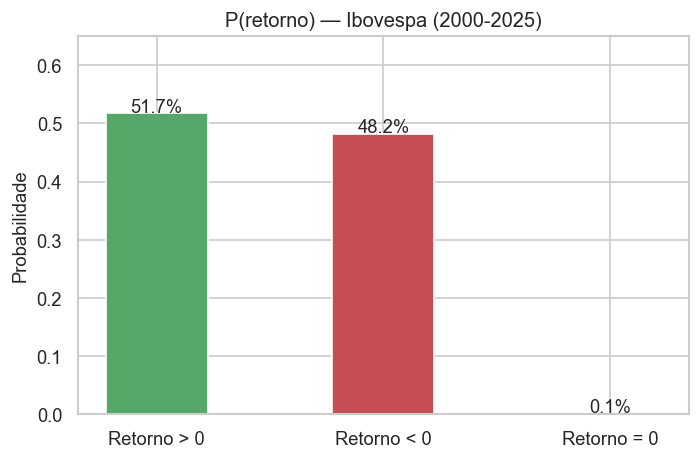

In [86]:
# --- Probabilidade Marginal (Frequentista) ---
p_pos = (ret_vals > 0).mean()
p_neg = (ret_vals < 0).mean()
p_zer = (ret_vals == 0).mean()

print('Probabilidade Simples (Marginal) — Ibovespa (2000-2025):')
print(f'  P(retorno > 0) = {p_pos:.4f}  ({p_pos*100:.1f}%)')
print(f'  P(retorno < 0) = {p_neg:.4f}  ({p_neg*100:.1f}%)')
print(f'  P(retorno = 0) = {p_zer:.4f}   ({p_zer*100:.1f}%)')
print(f'  Soma           = {p_pos + p_neg + p_zer:.4f}')

# --- P1: Evento impossível — P(retorno exatamente igual a +10% num dia) ---
p_impossivel = (ret_vals == 0.10).mean()
print(f'\nP1 — Evento impossível:')
print(f'  P(retorno = exatamente +10%) = {p_impossivel:.6f}  (aprox. zero)')

# --- P2: Complementar ---
print(f'\nP2 — Complementar:')
print(f'  P(retorno > 0)          = {p_pos:.4f}')
print(f'  P(retorno nao positivo) = {1 - p_pos:.4f}  (= 1 - P(retorno > 0))')

# --- P3: Adição — P(alta > 1% OU queda > 1%) ---
p_alta_grande  = (ret_vals >  0.01).mean()
p_queda_grande = (ret_vals < -0.01).mean()
p_intersec     = ((ret_vals > 0.01) & (ret_vals < -0.01)).mean()  # impossível, = 0
p_uniao        = p_alta_grande + p_queda_grande - p_intersec
print(f'\nP3 — Adicao (eventos disjuntos neste caso):')
print(f'  P(alta > 1%)             = {p_alta_grande:.4f}')
print(f'  P(queda > 1%)            = {p_queda_grande:.4f}')
print(f'  P(alta > 1% OU queda > 1%) = {p_uniao:.4f}  (soma direta pois sao disjuntos)')

# --- P4: Monotonicidade — P(alta > 2%) <= P(alta > 1%) <= P(alta > 0%) ---
p_alta_0 = (ret_vals > 0.00).mean()
p_alta_1 = (ret_vals > 0.01).mean()
p_alta_2 = (ret_vals > 0.02).mean()
print(f'\nP4 — Monotonicidade:')
print(f'  P(retorno > 0%) = {p_alta_0:.4f}')
print(f'  P(retorno > 1%) = {p_alta_1:.4f}  <= P(retorno > 0%)')
print(f'  P(retorno > 2%) = {p_alta_2:.4f}  <= P(retorno > 1%)')

# Gráfico: probabilidade marginal
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Retorno > 0', 'Retorno < 0', 'Retorno = 0'],
    [p_pos, p_neg, p_zer],
    color=['#55A868', '#C44E52', '#8C8C8C'],
    edgecolor='white', width=0.45
)
for bar, val in zip(bars, [p_pos, p_neg, p_zer]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val*100:.1f}%', ha='center', fontsize=11)
ax.set_ylim(0, 0.65)
ax.set_ylabel('Probabilidade', fontsize=11)
ax.set_title('P(retorno) — Ibovespa (2000-2025)', fontsize=12)
plt.tight_layout()
plt.show()


In [87]:
ret_series = retorno.squeeze()
hoje_arr = ret_series.values[1:]
ontem_arr = ret_series.values[:-1]

p_pos_dado_pos = (hoje_arr[ontem_arr > 0] > 0).mean()
p_pos_dado_neg = (hoje_arr[ontem_arr < 0] > 0).mean()

print("Probabilidade condicional — dia de hoje dado o dia anterior:")
print(f"  P(hoje > 0 | ontem > 0) = {p_pos_dado_pos:.4f}  ({p_pos_dado_pos*100:.1f}%)")
print(f"  P(hoje > 0 | ontem < 0) = {p_pos_dado_neg:.4f}  ({p_pos_dado_neg*100:.1f}%)")
print(f"  P(hoje > 0) marginal    = {p_pos:.4f}  ({p_pos*100:.1f}%)")

dif = abs(p_pos_dado_pos - p_pos_dado_neg)
print(f"\n  Diferenca entre condicionais: {dif*100:.1f} pp")
if dif < 0.03:
    print("  -> O retorno de ontem tem pouca influencia — mercado aproximadamente eficiente.")
else:
    print(f"  -> Diferenca relevante: o retorno de ontem influencia o de hoje.")

Probabilidade condicional — dia de hoje dado o dia anterior:
  P(hoje > 0 | ontem > 0) = 0.5118  (51.2%)
  P(hoje > 0 | ontem < 0) = 0.5227  (52.3%)
  P(hoje > 0) marginal    = 0.5171  (51.7%)

  Diferenca entre condicionais: 1.1 pp
  -> O retorno de ontem tem pouca influencia — mercado aproximadamente eficiente.


Probabilidade Conjunta — independencia entre dias consecutivos:
  P(A)          = P(hoje > 0)              = 0.5172
  P(B)          = P(ontem > 0)             = 0.5172
  P(A e B) real                            = 0.2647
  P(A) x P(B)  (se independentes)          = 0.2675
  Diferenca                                = 0.0028

-> P(A e B) ≈ P(A) x P(B): eventos aproximadamente INDEPENDENTES.
   O retorno de ontem nao ajuda a prever o de hoje — consistente com mercado eficiente.


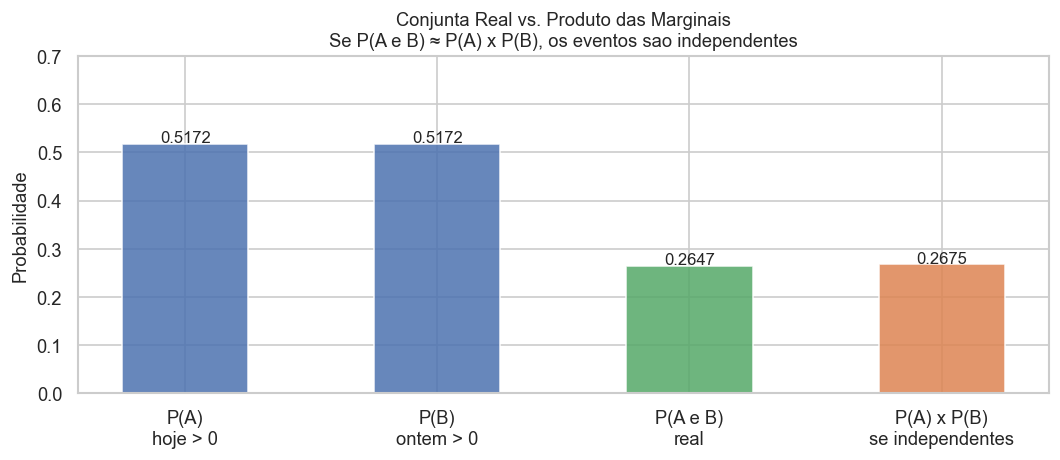

In [88]:
# Probabilidade Conjunta: P(A e B) vs. P(A) x P(B)
# Pergunta: hoje positivo E ontem positivo sao independentes?

ret_series = retorno.squeeze().values
hoje_arr   = ret_series[1:]
ontem_arr  = ret_series[:-1]

# Eventos
# A = hoje positivo
# B = ontem positivo
p_a       = (hoje_arr > 0).mean()                          # P(A)
p_b       = (ontem_arr > 0).mean()                         # P(B)
p_a_e_b   = ((hoje_arr > 0) & (ontem_arr > 0)).mean()      # P(A e B) — real
p_indep   = p_a * p_b                                      # P(A) x P(B) — se fossem independentes

print('Probabilidade Conjunta — independencia entre dias consecutivos:')
print(f'  P(A)          = P(hoje > 0)              = {p_a:.4f}')
print(f'  P(B)          = P(ontem > 0)             = {p_b:.4f}')
print(f'  P(A e B) real                            = {p_a_e_b:.4f}')
print(f'  P(A) x P(B)  (se independentes)          = {p_indep:.4f}')
print(f'  Diferenca                                = {abs(p_a_e_b - p_indep):.4f}')
print()
if abs(p_a_e_b - p_indep) < 0.01:
    print('-> P(A e B) ≈ P(A) x P(B): eventos aproximadamente INDEPENDENTES.')
    print('   O retorno de ontem nao ajuda a prever o de hoje — consistente com mercado eficiente.')
else:
    print('-> P(A e B) != P(A) x P(B): eventos DEPENDENTES.')
    print('   O retorno de ontem influencia o de hoje.')

# Visualizacao
import matplotlib.pyplot as plt
import numpy as np

labels = ['P(A)\nhoje > 0', 'P(B)\nontem > 0', 'P(A e B)\nreal', 'P(A) x P(B)\nse independentes']
valores = [p_a, p_b, p_a_e_b, p_indep]
cores   = ['#4C72B0', '#4C72B0', '#55A868', '#DD8452']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, valores, color=cores, edgecolor='white', width=0.5, alpha=0.85)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=10)

ax.set_ylabel('Probabilidade', fontsize=11)
ax.set_title(
    'Conjunta Real vs. Produto das Marginais\n'
    'Se P(A e B) ≈ P(A) x P(B), os eventos sao independentes',
    fontsize=11
)
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()


In [89]:
# Atualização bayesiana: P(queda amanhã | queda hoje)
#
# Definições:
#   A = 'retorno de amanhã < 0'
#   B = 'retorno de hoje < 0'
#
# P(A)        = prior  — frequência histórica de queda
# P(B|A)      = verossimilhança — frequência de queda hoje dado que amanhã também cai
# P(B)        = probabilidade marginal de queda hoje
# P(A|B)      = posterior — prob. de queda amanhã dado que hoje caiu

ret_series = retorno.squeeze().values
hoje_arr   = ret_series[:-1]   # dias t
amanha_arr = ret_series[1:]    # dias t+1

# Prior: P(A) = P(amanhã < 0)
p_a = (amanha_arr < 0).mean()

# P(B) = P(hoje < 0)
p_b = (hoje_arr < 0).mean()

# P(B|A) = P(hoje < 0 | amanhã < 0)
mask_a = amanha_arr < 0
p_b_dado_a = (hoje_arr[mask_a] < 0).mean()

# Posterior via Teorema de Bayes: P(A|B) = P(B|A) * P(A) / P(B)
p_a_dado_b = (p_b_dado_a * p_a) / p_b

# Verificação direta (frequentista)
mask_b = hoje_arr < 0
p_a_dado_b_direto = (amanha_arr[mask_b] < 0).mean()

print('Atualização Bayesiana — P(queda amanhã | queda hoje):')
print(f'  P(A)   — prior (P queda amanhã)          : {p_a:.4f}  ({p_a*100:.1f}%)')
print(f'  P(B)   — P(queda hoje)                   : {p_b:.4f}  ({p_b*100:.1f}%)')
print(f'  P(B|A) — verossimilhança                 : {p_b_dado_a:.4f}  ({p_b_dado_a*100:.1f}%)')
print(f'  P(A|B) — posterior via Bayes             : {p_a_dado_b:.4f}  ({p_a_dado_b*100:.1f}%)')
print(f'  P(A|B) — verificação direta              : {p_a_dado_b_direto:.4f}  ({p_a_dado_b_direto*100:.1f}%)')
print()
print(f'  Prior  -> Posterior: {p_a*100:.1f}% -> {p_a_dado_b*100:.1f}%')
if p_a_dado_b > p_a:
    print(f'  -> Observar queda hoje AUMENTA a probabilidade de queda amanhã.')
else:
    print(f'  -> Observar queda hoje não altera significativamente a probabilidade de queda amanhã.')


Atualização Bayesiana — P(queda amanhã | queda hoje):
  P(A)   — prior (P queda amanhã)          : 0.4822  (48.2%)
  P(B)   — P(queda hoje)                   : 0.4822  (48.2%)
  P(B|A) — verossimilhança                 : 0.4769  (47.7%)
  P(A|B) — posterior via Bayes             : 0.4769  (47.7%)
  P(A|B) — verificação direta              : 0.4769  (47.7%)

  Prior  -> Posterior: 48.2% -> 47.7%
  -> Observar queda hoje não altera significativamente a probabilidade de queda amanhã.


> **Conexão:** probabilidade é a linguagem da incerteza. Um modelo é a estrutura que usamos para organizar essa incerteza de forma matemática — transformando distribuições e probabilidades em previsões e decisões.

## 7. O que é um Modelo?

### 7.1 Definição

Um **modelo** é uma representação simplificada da realidade — uma forma de descrever, explicar ou prever fenômenos usando matemática. Todo modelo parte de uma escolha: quais aspectos da realidade incluir, quais ignorar e qual estrutura matemática usar para ligar uma coisa à outra.

Formalmente, um modelo estatístico é uma família de distribuições de probabilidade parametrizadas:

$$\mathcal{M} = \{ P_\theta : \theta \in \Theta \}$$

onde $\theta$ são os parâmetros estimados a partir dos dados e $\Theta$ é o espaço de parâmetros admissíveis.

---

### 7.2 Definição Pessoal

> Um modelo é uma aposta intelectual. Você escolhe quais aspectos da realidade incluir, quais ignorar e qual forma matemática usar para ligar uma coisa à outra. Toda vez que rodo um modelo, estou dizendo: *"Acredito que a realidade funciona assim — agora vou ver se os dados concordam."*
>
> O que me fascina é que modelos nunca são verdadeiros, mas podem ser úteis. O GARCH não descreve como o mundo realmente funciona — ele captura *padrão suficiente* de como a volatilidade se comporta para que eu possa tomar decisões melhores do que sem ele. Em risco de mercado, isso tem consequências reais: um modelo ruim significa capital mal alocado, posições mal dimensionadas e perdas inesperadas.
>
> Por isso modelar é uma habilidade que vai muito além do código: exige saber quando *não* confiar no modelo.

### 7.3 Modelos Estatísticos vs. Modelos de Machine Learning

Embora ambos aprendam padrões a partir de dados, a diferença fundamental está na **orientação**:

| Dimensão | Modelo Estatístico | Modelo de Machine Learning |
|----------|-------------------|---------------------------|
| **Orientação** | Inferência — entender *por que* | Predição — estimar *o quê* com máxima acurácia |
| **Hipótese de distribuição** | Explícita e central (ex: Normal, Poisson) | Geralmente implícita ou ausente |
| **Parâmetros** | Poucos, interpretáveis (ex: $\mu$, $\sigma$) | Muitos, frequentemente opacos (ex: pesos de uma rede neural) |
| **Incerteza** | Quantificada via intervalos de confiança e p-valores | Raramente quantificada (exceto modelos bayesianos) |
| **Generalização** | Depende de suposições sobre os dados | Aprende padrões sem suposições explícitas |
| **Risco de overfitting** | Menor (modelos mais parcimoniosos) | Maior (modelos mais flexíveis) |
| **Exemplos** | Regressão linear, GARCH, ARIMA | Random Forest, LSTM, XGBoost |

Na prática, a fronteira entre os dois é cada vez mais tênue. Modelos como o **LASSO** são estatísticos com regularização inspirada em ML; modelos como o **LSTM** podem ser usados dentro de frameworks probabilísticos bayesianos.


## Referências

- Magalhães, M. N.; Lima, A. C. P. — *Noções de Probabilidade e Estatística* (IME-USP)
- Triola, M. F. — *Introdução à Estatística*
- Morettin, P. A.; Toloi, C. M. — *Análise de Séries Temporais*
- Yahoo Finance — Ibovespa (^BVSP)